<a href="https://colab.research.google.com/github/pi-squared/opencv/blob/master/Midterm_HarmonicOscillatorPotential.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Harmonic Oscillator

This notebook is dedicated to the numerical solutions of the 1D harmonic oscillator quantum system. The starting point is the stationary Schrödinger equation:
$$
\hat{H}\Psi_n\left(x\right) = E_n \Psi_n\left(x\right),
$$
where $\hat{H}$ is the Hamiltonian of the system, that is built of the kinetic energy operator $\hat{T}$ and potential energy operator $\hat{V}$:
$$
\hat{H} = \hat{T} + \hat{V}.
$$
The kinetic energy operator for an electron ($m$ is its mass):
$$
\hat{T} = -\frac{\hbar^2}{2m}\frac{\mathrm{d}^2}{\mathrm{d}x^2}.
$$
The potential energy operator is a multiplication with potential profile $V(x)$. The harmonic oscillator potential has the follwing form:
$$
V(x) = \frac{1}{2}m\omega^2x^2
$$
where $m$ is again the electron mass, and $\omega$ gives an indication of the depth of the potential.
Finally, the eigenproblem is following:
$$
\left[-\frac{\hbar^2}{2m}\frac{\mathrm{d}^2}{\mathrm{d}x^2} + \frac{1}{2}m\omega^2x^2\right]\Psi_n\left(x\right) = E_n \Psi_n\left(x\right).
$$

In [ ]:
!pip install ipympl
# Numpy module for numerical matrix computations
import numpy as np
# Module for the physical constants
import scipy.constants as const
# Plotting library
import matplotlib.pyplot as plt
#%matplotlib inline
#Some extra libraries for widget animations
#!pip install ipympl #Needed for Google Colaboratory
%matplotlib widget
import ipywidgets as widgets

from google.colab import output #Needed for Google Colaboratory
output.enable_custom_widget_manager() #Needed for Google Colaboratory

Text(0, 0.5, 'V(x), eV')

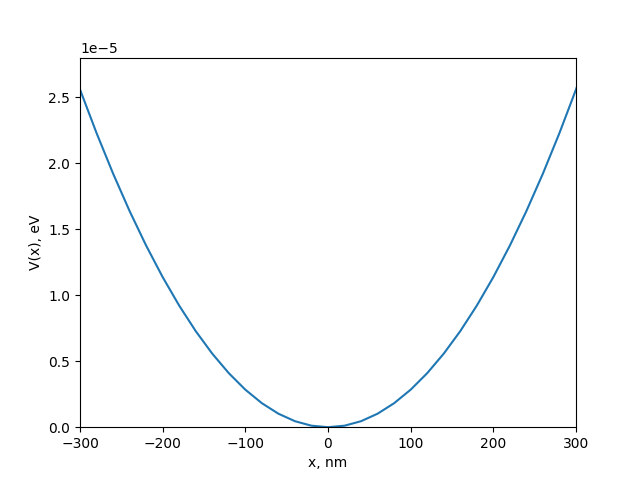

In [ ]:
# Potential profile parameters:
# a [nm]
a_nm = 10000
# V0 [eV]
V0_eV = 1e-6
# Converting the constants to SI:
a = a_nm*1e-9
V0 = V0_eV*const.e
#V0_inf = 0 #10000.0*const.e

omega = 1e10
m_electron = const.m_e



# Potential profile:
def Vi(x):
  return (1/2)*m_electron*(omega**2)*(x**2)
  #return np.where(x<-a, V0_inf,
            #np.where((x>=-a)&(x<=a), (1/2)*m_electron*(omega**2)*(x**2), V0_inf))

#Number of points
N = 1001
# Creating the mesh of x points:
x = np.linspace(-1*a,1*a,N)
# Creating the potential profile V(x):
V = Vi(x)

# Plotting the potential profile:
fig1 = plt.figure()
ax1  = fig1.add_subplot(1,1,1)
ax1.plot(x*1e9,V/const.e)
ax1.set_ylim((0,28*V0/const.e))
ax1.set_xlim((-300,300))
ax1.set_xlabel("x, nm")
ax1.set_ylabel("V(x), eV")

# Analytical solution

The analytical solution to the harmonic oscillator problem is well studied in textbooks on quantum mechanics.

The two main approaches consist of either solving the Schrodinger equation using an infinite power series approach resulting in solutions involving the Hermite polynomials or using an algebraic approach involving ladder operators. We won't discuss these solutions in detail here but they are well explained in textbooks such as Griffiths, Quantum Mechanics.

We will simply note the analytical solutions found from these methods here.

The energy eigenvalues are found to have the following form:
$$
E_n = (n + \frac{1}{2})\hbar\omega, \forall n \in [0,\infty)
$$
$E_0$ is what is known as the ground state energy. Notice that the energy eigenvalues are actually all equally spaced by the value $\hbar\omega$.

The energy eigenfunctions take the following form:

$$
\psi_n(x) = N_n H_n(x)e^{-x^2/2}
$$

where $N_n = \frac{1}{(2^n n! \sqrt{\pi})^{1/2}}$ is the normalisation constant and $H_n(x) = (-1)^n e^{x^2}\frac{d^n}{dx^n}e^{-x^2}$ are the Hermite polynomials.

We'll be able to confirm our numerical solutions by comparing with the analytical solutions above.

We'll now use the universal numerical way to reconstruct the wavefunctions that we also used for the double well potential.

# Numerical 1D solver

Starting from the same 1D Schrodinger equation:
$$
\left[-\frac{\hbar^2}{2m}\frac{\mathrm{d}^2}{\mathrm{d}x^2} + V\left(x\right)\right]\Psi\left(x\right) = E \Psi\left(x\right).
$$
wihh the harmonic oscillator potential:
$$
V(x) = \frac{1}{2}m\omega^2x^2
$$

The boundaries $[-a, a]$ are made large so that the numerical solutions are well matched with the analytical solutions.

The $\left[-a,a\right]$ region is splitted with step $h$:
$$
\left\{-a, -a+h, -a+2h, \dots, a-2h, a-h, a \right\}.
$$
Here we assume that we have $N$ points.

The derivative $\frac{\mathrm{d^2}\Psi}{\mathrm{d}x^2}$ has the following discrete form:
$$
\frac{\mathrm{d^2}\Psi(x_j)}{\mathrm{d}x^2} = \frac{\Psi_{j-1}-2\Psi_j+\Psi_{j+1}}{h^2}
$$
Then for any point from $j=1$ to $j=N-1$ one can write the equation:
$$
-\frac{\hbar^2}{2mh^2} \left( \Psi_{j-1}-2\Psi_j+\Psi_{j+1} \right) + V_j \Psi_j = E\Psi_j,
$$
That is in fact the system of linear equations, rewritable in matrix form:
$$
\left[ \begin{matrix}
\left(\frac{\hbar^2}{mh^2} + V_2\right) & -\frac{\hbar^2}{2mh^2} & 0 & \cdots & 0 \\
-\frac{\hbar^2}{2mh^2} & \left(\frac{\hbar^2}{mh^2} + V_3\right) & -\frac{\hbar^2}{2mh^2} & \cdots & 0 \\
0&-\frac{\hbar^2}{2mh^2} & \left(\frac{\hbar^2}{mh^2} + V_4\right) & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \cdots & \left(\frac{\hbar^2}{mh^2} + V_{N-1}\right)
\end{matrix} \right]
\left[ \begin{matrix}
\Psi_2 \\
\Psi_3 \\
\Psi_4 \\
\vdots \\
\Psi_{N-1}
\end{matrix}
\right] = E \left[ \begin{matrix}
\Psi_2 \\
\Psi_3 \\
\Psi_4 \\
\vdots \\
\Psi_{N-1}
\end{matrix}
\right].
$$

In fact, this means that instead of the eigenproblem with differential operators we should solve the eigenproblem for the matrix that is relatively simple.

In [ ]:
# Building the matrix:
M = np.zeros((N-2,N-2))
for i in range(N-2):
  M[i][i] = const.hbar**2/(const.m_e*(x[1]-x[0])**2) + V[i+1]
  if(i!=0):
    M[i][i-1] = -const.hbar**2/(2.0*const.m_e*(x[1]-x[0])**2)
  if(i!=N-3):
    M[i][i+1] = -const.hbar**2/(2.0*const.m_e*(x[1]-x[0])**2)

# Obtaining the eigenvalues and eigenvectors:
from numpy.linalg import eig
eval, evec = eig(M)
# Transposing the evec matrix (because eigenfunctions are columns by default)
evec = np.transpose(evec)
# Sorting Eigenvalues and Eigenvectors:
idx = eval.argsort()
eval = eval[idx]
evec = evec[idx] #Still a valid eigenvector if need to multiply by minus 1


In [ ]:
#To print the numerical eigen energies you can find them in the eval array

#First eigenenergy converted to electronvolts
eval[0]/const.e

#Second eigenenergy converted to electronvolts
eval[1]/const.e

#Let's compare the numerical ground state energy with the analytical solution
print("Numerical Ground State Energy: " + str(eval[0]/const.e) + " eV")
print("Analytical Ground State Energy: " + str((const.hbar*omega/2)/const.e) + " eV")

#Notice they are very close in value, we could improve this further by increase the boundary a.
#You could try decreasing the boundary a and see the analytical and numerical solutions diverge.
(eval[1]-eval[0])/(2*const.pi*const.hbar)

Numerical Ground State Energy: 3.283937299101028e-06 eV
Analytical Ground State Energy: 3.2910597847545335e-06 eV


1584645504.4236336

Text(0, 0.5, '$E$, eV')

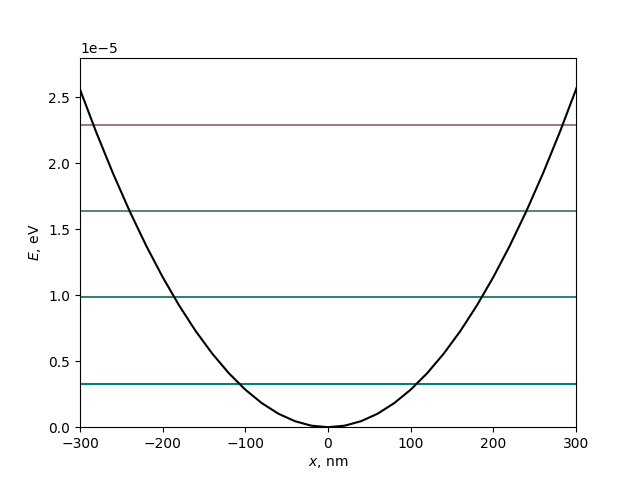

In [ ]:
# Drawing the energy levels:
fig2 = plt.figure()
ax2 = fig2.add_subplot(1,1,1)
#ax2.set_ylim((-0.02,1.2*V0/const.e))

# Number of states
Nst=5

for i in range(Nst):
    ax2.plot(np.array([-a,a])*1e9,np.array([eval[i],eval[i]])/const.e, color = (i/Nst,0.5,0.5))
ax2.plot(x*1e9,V/const.e,"k")
ax2.set_ylim((0,28*V0/const.e))
ax2.set_xlim((-300,300))
ax2.set_xlabel("$x$, nm")
ax2.set_ylabel("$E$, eV")


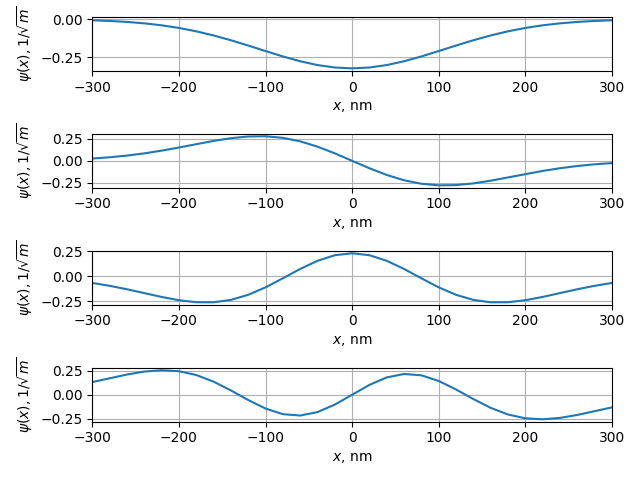

In [ ]:
#Plot the first 4 eigenfunctions (these are the wavefunctions)
fig3 = plt.figure()

for i in range(4):
  ax3 = fig3.add_subplot(4,1,i+1)
  ax3.plot(x[1:N-1]*1e9, evec[i])
  ax3.set_xlabel("$x$, nm")
  ax3.set_ylabel("$\\psi(x), 1/\\sqrt{m}$")
  ax3.set_xlim((-300,300))
  ax3.grid()
fig3.tight_layout()

# Questions and practical tasks

* Are the eigenfunctions normalised?

In [ ]:
# Check that the inner product of an eigenfunction with itself is 1
print(np.inner(np.conj(evec[0]), evec[0]))

# Check that the inner product of an eigenfunction with a different eigenfunction is 0
print(np.inner(np.conj(evec[0]), evec[1]))

1.0
-2.2412627309620348e-15


*	Let's create a superposition of the solution wavefunctions
*	Where can you use these wavefunctions in terms of quantum computing?

interactive(children=(FloatSlider(value=0.0, description='theta', max=3.141592653589793, step=0.00314159265358…

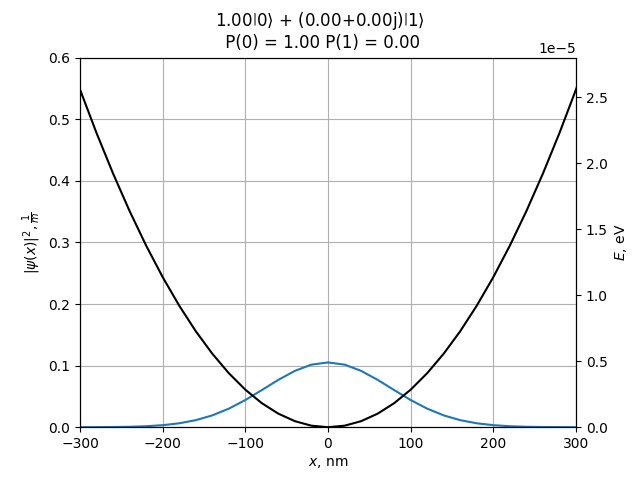

In [ ]:
#Superposition of the first two eigenfunctions
fig4 = plt.figure()
ax4 = fig4.add_subplot(1,1,1)
ax41 = ax4.twinx()

fig4.canvas.toolbar_visible = True
fig4.canvas.header_visible = False
fig4.canvas.footer_visible = False

#plt.plot(x[1:N-1]*1e9, evec[i])

@widgets.interact(theta=(0, np.pi, np.pi/1000), gamma=(0, 2*np.pi, np.pi/1000))
def update1(theta=0, gamma=0):
    """Remove old lines from plot and plot new one"""
    ax4.clear()
    alpha = np.cos(theta/2)
    beta  = np.exp(1j*gamma)*np.sin(theta/2)
    state = alpha*evec[0] + beta*evec[1]
    prob_0 = np.abs(alpha)**2
    prob_1 = np.abs(beta)**2
    fig4.suptitle("{:.2f}".format(alpha) + r"$\left|0\right\rangle$" + " + " + "({:.2f})".format(beta) + r"$\left|1\right\rangle$" + "\n P(0) = {:.2f}".format(prob_0) + " P(1) = {:.2f}".format(prob_1), y = 0.98)
    ax4.plot(x[1:N-1]*1e9, np.abs(state)**2)
    ax41.plot(x*1e9,V/const.e,"k")
    ax41.set_ylabel("$E$, eV")
    ax41.set_ylim((0,28*V0/const.e))
    ax41.set_xlim((-300,300))
    ax4.set_ylim((0,0.6))
    ax4.set_xlabel("$x$, nm")
    ax4.set_ylabel(r"$|\psi(x)|^2, \frac{1}{m}$")
    ax4.grid()
    print ("Energy 1", eval[0]/const.e)
    print ("Energy 2", eval[1]/const.e)

* What does time evolution look like if we start with an eigenstate?

$$|\psi\rangle = e^{\frac{-iE_{0}t}{\hbar}}|0\rangle $$

interactive(children=(FloatSlider(value=0.0, description='time', max=1.0, step=0.01), Output()), _dom_classes=…

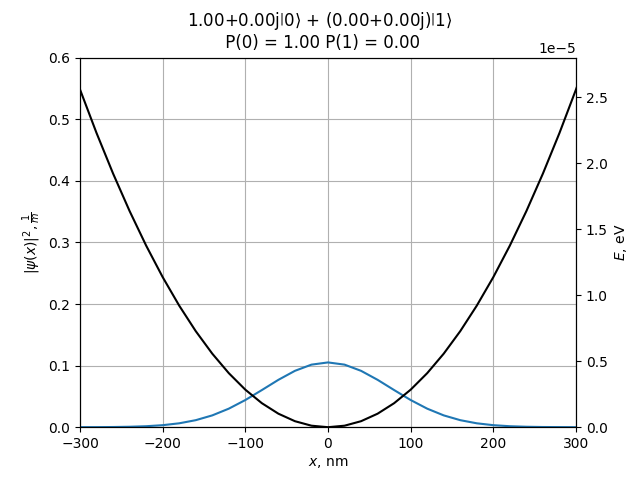

In [ ]:
#Start with initial state as first eigenfunction
fig5 = plt.figure()
ax5 = fig5.add_subplot(1,1,1)
ax51 = ax5.twinx()

fig5.canvas.toolbar_visible = True
fig5.canvas.header_visible = False
fig5.canvas.footer_visible = False

@widgets.interact(time=widgets.FloatSlider(min=0, max=1, value=0, step=1e-2, valfmt="{:.2f}"))
def update1(time=0):
    """Remove old lines from plot and plot new one"""
    ax5.clear()
    #Our initial state is just the ground state eigenfunction
    alpha = 1
    beta  = 0
    alpha_time = alpha*np.exp(-1j*eval[0]*time/const.hbar)
    beta_time  = beta*np.exp(-1j*eval[1]*time/const.hbar)
    state = alpha_time*evec[0] + beta_time*evec[1]
    prob_0 = np.abs(alpha_time)**2
    prob_1 = np.abs(beta_time)**2
    fig5.suptitle("{:.2f}".format(alpha_time) + r"$\left|0\right\rangle$" + " + " + "({:.2f})".format(beta_time) + r"$\left|1\right\rangle$" + "\n P(0) = {:.2f}".format(prob_0) + " P(1) = {:.2f}".format(prob_1), y = 0.98)
    ax5.plot(x[1:N-1]*1e9, np.abs(state)**2)
    ax51.plot(x*1e9,V/const.e,"k")
    ax51.set_ylabel("$E$, eV")
    ax51.set_ylim((0,28*V0/const.e))
    ax51.set_xlim((-300,300))
    ax5.set_ylim((0,0.6))
    ax5.set_xlabel("$x$, nm")
    ax5.set_ylabel(r"$|\psi(x)|^2, \frac{1}{m}$")
    ax5.grid()

* What about when we start in an equal superposition of eigenstates?

$$|\psi\rangle = \frac{1}{\sqrt{2}}|0\rangle e^{\frac{-iE_{0}t}{\hbar}} + \frac{1}{\sqrt{2}}|1\rangle e^{\frac{-iE_{1}t}{\hbar}}$$

interactive(children=(FloatSlider(value=0.0, description='time', max=1.0, step=0.01), Output()), _dom_classes=…

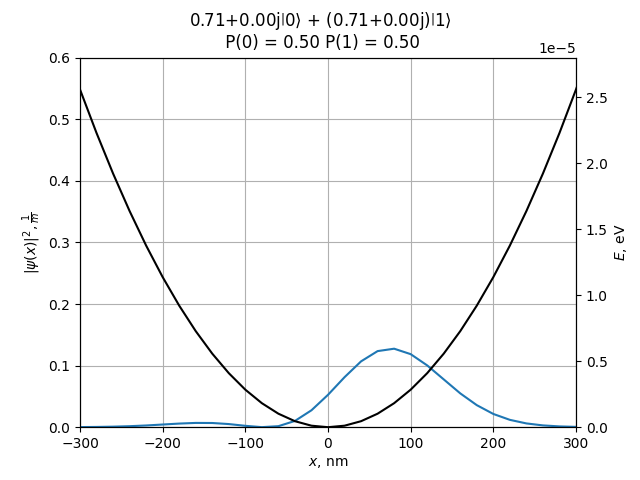

In [ ]:
#Start with an equal superposition of eigenstates
fig6 = plt.figure()
ax6 = fig6.add_subplot(1,1,1)
ax61 = ax6.twinx()

fig6.canvas.toolbar_visible = True
fig6.canvas.header_visible = False
fig6.canvas.footer_visible = False

@widgets.interact(time=widgets.FloatSlider(min=0, max=1, value=0, step=1e-2, valfmt="{:.2f}"))
def update1(time=0):
    """Remove old lines from plot and plot new one"""
    ax6.clear()
    #Our initial state is an equal superposition of the ground state eigenfunction and first excited state
    alpha = 1/np.sqrt(2)
    beta  = 1/np.sqrt(2)
    alpha_time = alpha*np.exp(-1j*eval[0]*time/const.hbar)
    beta_time  = beta*np.exp(-1j*eval[1]*time/const.hbar)
    state = alpha_time*evec[0] + beta_time*evec[1]
    prob_0 = np.abs(alpha_time)**2
    prob_1 = np.abs(beta_time)**2
    fig6.suptitle("{:.2f}".format(alpha_time) + r"$\left|0\right\rangle$" + " + " + "({:.2f})".format(beta_time) + r"$\left|1\right\rangle$" + "\n P(0) = {:.2f}".format(prob_0) + " P(1) = {:.2f}".format(prob_1), y = 0.98)
    ax6.plot(x[1:N-1]*1e9, np.abs(state)**2)
    ax61.plot(x*1e9,V/const.e,"k")
    ax61.set_ylabel("$E$, eV")
    ax61.set_ylim((0,28*V0/const.e))
    ax61.set_xlim((-300,300))
    ax6.set_ylim((0,0.6))
    ax6.set_xlabel("$x$, nm")
    ax6.set_ylabel(r"$|\psi(x)|^2, \frac{1}{m}$")
    ax6.grid()